# Карточка решения

## Название проекта

Прогнозирование задержек авиарейсов (Flight Delays Fall 2018)

## Источник данных

Данные получены из соревнования Kaggle "Flight Delays Fall 2018".

## Цель работы

Разработать модель машинного обучения, способную предсказывать вероятность задержки вылета самолета более чем на 15 минут.

## Используемые технологии

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- CatBoost

## Модель

Основная модель — Logistic Regression.

Дополнительно протестирована модель CatBoostClassifier для повышения качества прогнозирования.

## Метрика

ROC AUC.

## Полученный результат

Среднее значение ROC AUC вычислено с помощью пятиблочной кросс-валидации.

## Ограничения данных

- данные содержат информацию только о рейсах из соревнования Kaggle;
- выборка не отражает все возможные авиаперевозки;
- данные относятся к историческому периоду и могут не соответствовать текущей ситуации;
- использование данных ограничено правилами соревнования Kaggle.


In [1]:
import os
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import hstack

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [2]:
DATA = "/kaggle/input/competitions/flight-delays-fall-2018"

train = pd.read_csv(f"{DATA}/flight_delays_train.csv.zip")
test = pd.read_csv(f"{DATA}/flight_delays_test.csv.zip")
submission = pd.read_csv(f"{DATA}/sample_submission.csv.zip")

print("Train:", train.shape)
print("Test :", test.shape)

train.head()

Train: (100000, 9)
Test : (100000, 8)


,Month,DayofMonth,DayOfWeek,DepTime,UniqueCarrier,Origin,Dest,Distance,dep_delayed_15min
0,c-8,c-21,c-7,1934,AA,ATL,DFW,732,N
1,c-4,c-20,c-3,1548,US,PIT,MCO,834,N
2,c-9,c-2,c-5,1422,XE,RDU,CLE,416,N
3,c-11,c-25,c-6,1015,OO,DEN,MEM,872,N
4,c-10,c-7,c-6,1828,WN,MDW,OMA,423,Y


In [3]:
train.info()

train.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Month              100000 non-null  object
 1   DayofMonth         100000 non-null  object
 2   DayOfWeek          100000 non-null  object
 3   DepTime            100000 non-null  int64 
 4   UniqueCarrier      100000 non-null  object
 5   Origin             100000 non-null  object
 6   Dest               100000 non-null  object
 7   Distance           100000 non-null  int64 
 8   dep_delayed_15min  100000 non-null  object
dtypes: int64(2), object(7)
memory usage: 6.9+ MB


,Month,DayofMonth,DayOfWeek,DepTime,UniqueCarrier,Origin,Dest,Distance,dep_delayed_15min
count,100000,100000,100000,100000.000000,100000,100000,100000,100000.00000,100000
unique,12,31,7,NaN,22,289,289,NaN,2
top,c-8,c-1,c-4,NaN,WN,ATL,ATL,NaN,N
freq,8830,3399,14736,NaN,15082,5834,5795,NaN,80956
mean,NaN,NaN,NaN,1341.523880,NaN,NaN,NaN,729.39716,NaN
std,NaN,NaN,NaN,476.378445,NaN,NaN,NaN,574.61686,NaN
min,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,30.00000,NaN
25%,NaN,NaN,NaN,931.000000,NaN,NaN,NaN,317.00000,NaN
50%,NaN,NaN,NaN,1330.000000,NaN,NaN,NaN,575.00000,NaN
75%,NaN,NaN,NaN,1733.000000,NaN,NaN,NaN,957.00000,NaN


In [4]:
train.isnull().sum()

Month                0
DayofMonth           0
DayOfWeek            0
DepTime              0
UniqueCarrier        0
Origin               0
Dest                 0
Distance             0
dep_delayed_15min    0
dtype: int64

In [5]:
def feature_engineering(df):

    df = df.copy()

    for col in ["Month", "DayofMonth", "DayOfWeek"]:
        df[col] = (
            df[col]
            .str.replace("c-", "", regex=False)
            .astype(int)
        )

    df["DepHour"] = df["DepTime"] // 100
    df["DepMinute"] = df["DepTime"] % 100

    df["IsWeekend"] = (df["DayOfWeek"] >= 6).astype(int)

    df["IsMorning"] = (
        (df["DepHour"] >= 6) &
        (df["DepHour"] < 12)
    ).astype(int)

    df["IsEvening"] = (
        df["DepHour"] >= 18
    ).astype(int)

    df["Route"] = df["Origin"] + "_" + df["Dest"]

    df["DistanceGroup"] = pd.cut(
        df["Distance"],
        bins=[0,500,1000,2000,10000],
        labels=[
            "Short",
            "Medium",
            "Long",
            "VeryLong"
        ]
    )

    return df

In [6]:
train = feature_engineering(train)
test = feature_engineering(test)

train["target"] = (
    train["dep_delayed_15min"]=="Y"
).astype(int)

train.head()

,Month,DayofMonth,DayOfWeek,DepTime,UniqueCarrier,Origin,Dest,Distance,dep_delayed_15min,DepHour,DepMinute,IsWeekend,IsMorning,IsEvening,Route,DistanceGroup,target
0,8,21,7,1934,AA,ATL,DFW,732,N,19,34,1,0,1,ATL_DFW,Medium,0
1,4,20,3,1548,US,PIT,MCO,834,N,15,48,0,0,0,PIT_MCO,Medium,0
2,9,2,5,1422,XE,RDU,CLE,416,N,14,22,0,0,0,RDU_CLE,Short,0
3,11,25,6,1015,OO,DEN,MEM,872,N,10,15,1,1,0,DEN_MEM,Medium,0
4,10,7,6,1828,WN,MDW,OMA,423,Y,18,28,1,0,1,MDW_OMA,Short,1


In [7]:
os.makedirs("/kaggle/working", exist_ok=True)

train.to_parquet(
    "/kaggle/working/train_processed.parquet",
    index=False
)

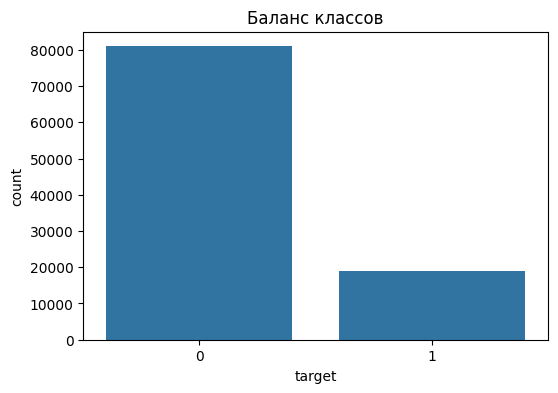

Доля задержанных рейсов: 0.19044


In [8]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="target",
    data=train
)

plt.title("Баланс классов")

plt.show()

print("Доля задержанных рейсов:",
      train["target"].mean())

### Вывод

По графику видно, что большинство рейсов не имеют задержки более 15 минут. Класс "без задержки" встречается значительно чаще, чем класс "задержка". Это говорит о несбалансированности выборки. При оценке качества модели целесообразно использовать метрику ROC AUC, так как обычная точность (Accuracy) может давать завышенную оценку качества.

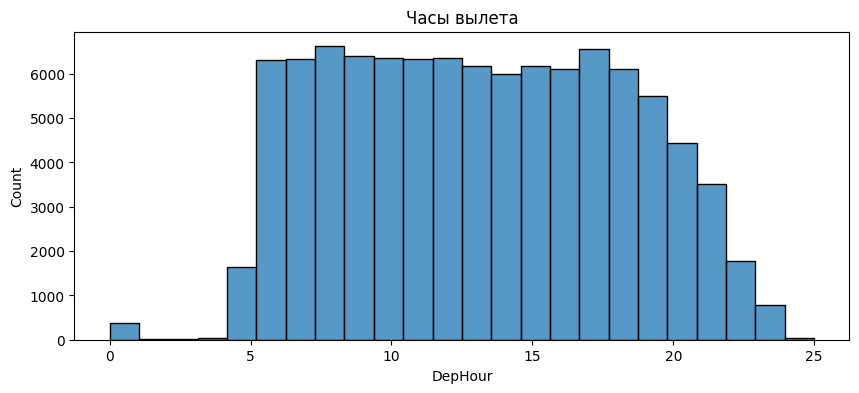

In [9]:
plt.figure(figsize=(10,4))

sns.histplot(
    train["DepHour"],
    bins=24
)

plt.title("Часы вылета")

plt.show()

### Вывод

Наибольшее количество рейсов выполняется в утренние и дневные часы. Вечерних и ночных рейсов значительно меньше. Время вылета может влиять на вероятность задержки, поэтому был создан дополнительный признак DepHour.

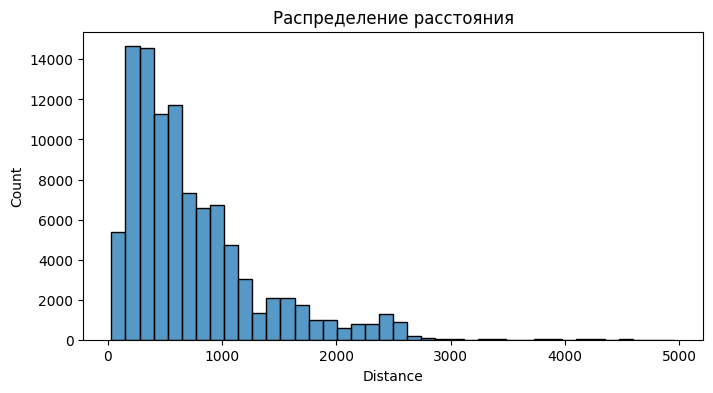

In [10]:
plt.figure(figsize=(8,4))

sns.histplot(
    train["Distance"],
    bins=40
)

plt.title("Распределение расстояния")

plt.show()

### Вывод

Большинство перелетов имеют небольшую или среднюю дальность. Дальнемагистральные рейсы встречаются значительно реже. Расстояние может косвенно влиять на вероятность задержки, поэтому этот признак используется при обучении модели.

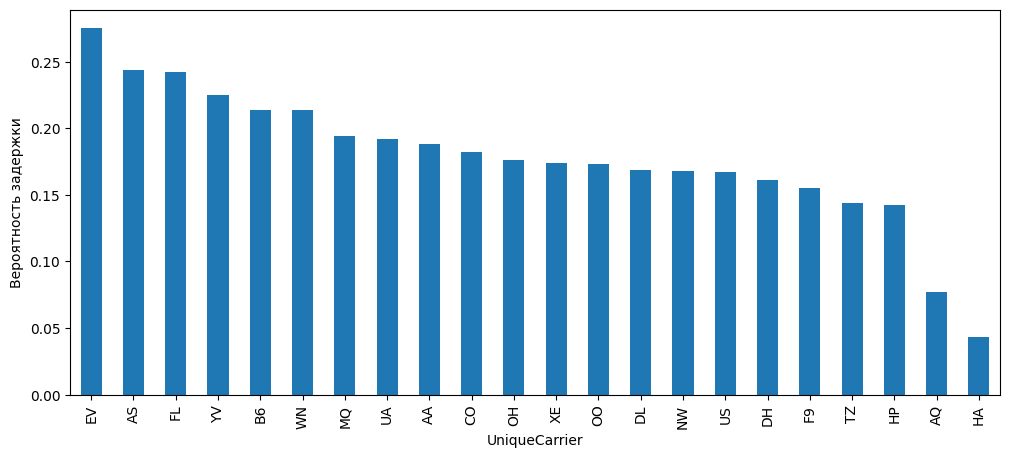

In [11]:
carrier_delay = (
    train.groupby("UniqueCarrier")["target"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,5))

carrier_delay.plot.bar()

plt.ylabel("Вероятность задержки")

plt.show()

### Вывод

Вероятность задержки различается между авиакомпаниями. Некоторые перевозчики имеют значительно более высокий процент задержек. Это подтверждает, что признак UniqueCarrier является информативным и должен использоваться при обучении модели.

In [12]:
NUM_FEATURES = [
    "Month",
    "DayofMonth",
    "DayOfWeek",
    "DepHour",
    "DepMinute",
    "Distance",
    "IsWeekend",
    "IsMorning",
    "IsEvening"
]

CAT_FEATURES = [
    "UniqueCarrier",
    "Origin",
    "Dest",
    "Route",
    "DistanceGroup"
]

In [13]:
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

encoder.fit(pd.concat([
    train[CAT_FEATURES],
    test[CAT_FEATURES]
]))

X = hstack([
    train[NUM_FEATURES],
    encoder.transform(train[CAT_FEATURES])
]).tocsr()

X_test = hstack([
    test[NUM_FEATURES],
    encoder.transform(test[CAT_FEATURES])
]).tocsr()

y = train["target"]

In [14]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = []

for train_idx, valid_idx in cv.split(X,y):

    X_train = X[train_idx]
    X_valid = X[valid_idx]

    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]

    model = LogisticRegression(
        max_iter=1200
    )

    model.fit(X_train,y_train)

    pred = model.predict_proba(X_valid)[:,1]

    auc = roc_auc_score(y_valid,pred)

    scores.append(auc)

print(scores)
print("Mean ROC AUC =", np.mean(scores))

[np.float64(0.6955753969695585), np.float64(0.7030179522576702), np.float64(0.7000045515337477), np.float64(0.7003505297153456), np.float64(0.7046228259757961)]
Mean ROC AUC = 0.7007142512904236


In [15]:
model = LogisticRegression(
    max_iter=1200
)

model.fit(X,y)

LogisticRegression(max_iter=1200)

In [16]:
prediction = model.predict_proba(X_test)[:,1]

In [17]:
submission["dep_delayed_15min"] = prediction

submission.to_csv(
    "/kaggle/working/submission.csv",
    index=False
)

submission.head()

,id,dep_delayed_15min
0,0,0.081746
1,1,0.124070
2,2,0.094078
3,3,0.248775
4,4,0.238563


In [18]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    eval_metric="AUC",
    random_seed=42,
    verbose=100
)

cat.fit(X, y)

prediction = cat.predict_proba(X_test)[:,1]

submission["dep_delayed_15min"] = prediction

submission.to_csv(
    "/kaggle/working/submission_catboost.csv",
    index=False
)

0:	total: 93.1ms	remaining: 27.8s
100:	total: 3.02s	remaining: 5.94s
200:	total: 5.86s	remaining: 2.88s
299:	total: 8.67s	remaining: 0us
